# 02 — LLM-as-Policy: Single-Agent Zero-Shot Battery Control

**Phase 2** · MSc Thesis

Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

Evaluates frontier LLMs as zero-shot battery controllers in a **single group-centralized agent setup** over 3 buildings (`TRAINING_BUILDINGS=[0,1,2]`).

One API call per step, 3 actions per call. Aligns with the Phase 3 SFT training shape — at Phase 4 deployment the same agent is instantiated twice (α on B0–2, β on B3–5) but **here we stay single-agent**.

**Rollout window:** 300 hourly steps starting at `t=3624`.

**Providers tested:**

| Provider | Model | API quirks |
|----------|-------|------------|
| Anthropic | `claude-haiku-4-5` | Native client; standard `max_tokens`, `temperature=0`. |
| DeepSeek | `deepseek-chat` (V3) | OpenAI-compat; standard `max_tokens`, `temperature=0`. |
| Kimi | `kimi-k2.5` | OpenAI-compat (Moonshot); **requires `temperature=1`**. |
| OpenAI | `gpt-5.4-nano` | Reasoning-family — uses **`max_completion_tokens`**, **`temperature=1`** only. |

**API keys:** loaded from `.env`. Required: `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`, `KIMI_API_KEY`, `OPENAI_API_KEY`.


## § 0 — Config
> **Change experiment parameters here only.** Nothing else needs editing.

In [1]:
import sys
from pathlib import Path

# ── Make src/ importable ──────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from src.env import TRAINING_BUILDINGS

# ── Provider list ─────────────────────────────────────────────────────────
PROVIDERS: list[dict] = [
    {"name": "anthropic", "model": "claude-haiku-4-5", "key_env": "ANTHROPIC_API_KEY", "base_url": None},
    {"name": "deepseek",  "model": "deepseek-chat",    "key_env": "DEEPSEEK_API_KEY",  "base_url": "https://api.deepseek.com/v1"},
    {"name": "kimi",      "model": "kimi-k2.5",         "key_env": "KIMI_API_KEY",      "base_url": "https://api.moonshot.ai/v1", "temperature": 1.0},
    {"name": "openai",    "model": "gpt-5.4-nano",      "key_env": "OPENAI_API_KEY",    "base_url": None},
]

# ── Single-agent buildings (Phase 3 design — see CLAUDE.md) ───────────────
BUILDINGS: list[int] = TRAINING_BUILDINGS   # [0, 1, 2]
N_BLDGS:   int        = len(BUILDINGS)

# ── Timeout ──────────────────────────────────────────────────────────────
LLM_TIMEOUT_S: float = 45.0

# ── Experiment window ─────────────────────────────────────────────────────
WEEK_START: int = 3624
WEEK_LEN:   int = 300

# ── Output ───────────────────────────────────────────────────────────────
ARTIFACTS = Path("artifacts").resolve()
ARTIFACTS.mkdir(exist_ok=True)

# ── Sanity print ─────────────────────────────────────────────────────────
import os
print(f"Project root   : {PROJECT_ROOT}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Single agent   : buildings {BUILDINGS}  (N_BLDGS={N_BLDGS})")
print(f"Timeout/call   : {LLM_TIMEOUT_S}s")
print(f"\nProviders ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    flag = "OK" if has_key else "MISSING"
    print(f"  [{flag}] {p['name']:10s} model={p['model']:35s} env={p['key_env']}")


Project root   : /Users/antonisbast/projects/eclipse-thesis
Window         : t3624..3923 (300 steps)
Single agent   : buildings [0, 1, 2]  (N_BLDGS=3)
Timeout/call   : 45.0s

Providers (4):
  [OK] anthropic  model=claude-haiku-4-5                    env=ANTHROPIC_API_KEY
  [OK] deepseek   model=deepseek-chat                       env=DEEPSEEK_API_KEY
  [OK] kimi       model=kimi-k2.5                           env=KIMI_API_KEY
  [OK] openai     model=gpt-5.4-nano                        env=OPENAI_API_KEY


## § 1 — Imports

In [2]:
import concurrent.futures
import json
import logging
import random
import time
import warnings

import citylearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from citylearn.citylearn import CityLearnEnv

# ── Single source of truth: everything domain-specific from src/ ──────────
from src.env       import SEED, make_env, snapshot_state
from src.agent     import (
    PRICE_PEAK_THRESHOLD,
    price_bucket, carbon_bucket, solar_bucket, irradiance_bucket,
    render_state, parse_actions, ACTION_RE,
    make_minimal_prompt, make_policy_llm,
    policy_noop, policy_random, policy_rbc,
)
from src.providers import APIProvider
from src.eval      import evaluate, comparison_table

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")
print("src.env, src.agent, src.providers, src.eval all loaded — no inline redefinitions.")


CityLearn 2.6.0b2
src.env, src.agent, src.providers, src.eval all loaded — no inline redefinitions.


## § 1b — Imports note

All domain helpers (state rendering, action parsing, prompt, `APIProvider`, reference policies) come from `src/`. No inline redefinitions in this notebook — `src.agent.make_minimal_prompt` is the canonical CoT prompt; `src.providers.APIProvider` handles remote APIs.


In [3]:
# All helpers imported from src/ in the previous cell.
# The canonical CoT prompt is previewed in § 4.
print('Domain helpers OK — see § 4 for the prompt preview.')

Domain helpers OK — see § 4 for the prompt preview.


## § 2 — Environment

In [4]:
_env = make_env(
    buildings=BUILDINGS,
    start=WEEK_START,
    end=WEEK_START + WEEK_LEN - 1,
    obs_set="llm",
    reward_fn="merlin",
)
_obs, _ = _env.reset()
print(f"buildings      : {len(_obs)}  (single-agent — {BUILDINGS})")
print(f"obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars)")
print(f"steps / episode: {_env.time_steps}")
print(f"reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)

print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building (all real-time):")
print(f"  month, day_type, hour, electricity_pricing, carbon_intensity,")
print(f"  solar_generation, non_shiftable_load, electrical_storage_soc,")
print(f"  net_electricity_consumption_last")

print(f"\nBuilding states at t=0:")
for i, d in enumerate(_snap):
    print(
        f"  B{i}: SoC={d['electrical_storage_soc']*100:.1f}%  "
        f"load={d['non_shiftable_load']:.2f}  "
        f"price={d['electricity_pricing']:.3f}  "
        f"solar={d['solar_generation']:.2f}"
    )


buildings      : 3  (single-agent — [0, 1, 2])
obs / building : 9  (llm obs set — 9 real-time vars)
steps / episode: 300
reward fn      : MERLINReward

snapshot_state() returns 9 fields per building (all real-time):
  month, day_type, hour, electricity_pricing, carbon_intensity,
  solar_generation, non_shiftable_load, electrical_storage_soc,
  net_electricity_consumption_last

Building states at t=0:
  B0: SoC=0.0%  load=0.60  price=0.210  solar=0.00
  B1: SoC=0.0%  load=1.68  price=0.210  solar=0.00
  B2: SoC=0.0%  load=0.28  price=0.210  solar=0.00


## § 3 — State Renderer

`snapshot_state()` returns **9 fields** per building — all real-time. The CityLearn
dataset also exposes oracle price/solar forecast columns, but we deliberately
exclude them (see notebook 01 § 2): they are perfect look-ahead reads from the
simulation tape, not a signal a deployed agent could obtain. The LLM is asked
to anticipate future conditions from real-time state alone.

`render_state()` converts the snapshot into a human-readable prompt string, e.g.:

```
Month 12, Wed 08:00  |  price=0.210 (LOW)  |  carbon=0.202 (PEAK)
Buildings:
  B0: SoC= 45.3%  load=1.20 kWh  last_net=+0.85 kWh  solar=LOW
  ...
```

Each agent receives only its **own 3 buildings**. `render_state()` re-labels from B0
regardless of the slice, so both agents see identically structured prompts.

In [5]:
# Single-agent state preview
print("=" * 60)
print(f"Agent state (buildings {BUILDINGS}):")
print("=" * 60)
print(render_state(_snap))


Agent state (buildings [0, 1, 2]):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE


## § 4 — Prompt Preview

`make_minimal_prompt(3)` is the active prompt — it is printed by the § 1b utilities cell
above and used automatically by every provider cell below.

In [6]:
# Show the prompt the agent will receive
print(make_minimal_prompt(N_BLDGS))


You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- No forecasts are provided. Plan ahead by predicting how price, solar, and lo

## § 5 — Provider Setup & Smoke Test

`PROVIDER_OBJS` is initialised in the first cell. Each subsequent cell smoke-tests
**one provider independently** — you can interrupt a hung cell without losing others.

Providers that fail (timeout, missing key, import error) are excluded from `PROVIDER_OBJS`
and automatically skipped by every rollout cell in §§ 9–12.

In [7]:
PROVIDER_OBJS: dict[str, APIProvider] = {}
print("PROVIDER_OBJS initialised — run per-provider smoke-test cells below.")
print(f"Providers configured in § 0: {[p['name'] for p in PROVIDERS]}")

PROVIDER_OBJS initialised — run per-provider smoke-test cells below.
Providers configured in § 0: ['anthropic', 'deepseek', 'kimi', 'openai']


In [8]:
# ── Smoke test: Anthropic ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "anthropic"), None)
if _spec is None:
    print("[anthropic] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["anthropic"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] anthropic  {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  [✓] anthropic:claude-haiku-4-5                    → 'PONG'
Active providers: ['anthropic']


In [9]:
# ── Smoke test: DeepSeek ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "deepseek"), None)
if _spec is None:
    print("[deepseek] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["deepseek"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] deepseek   {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] deepseek:deepseek-chat                        → 'PONG'
Active providers: ['anthropic', 'deepseek']


In [10]:
# ── Smoke test: Kimi / Moonshot ───────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "kimi"), None)
if _spec is None:
    print("[kimi] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["kimi"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] kimi       {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] kimi:kimi-k2.5                                → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi']


In [11]:
# ── Smoke test: OpenAI ────────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "openai"), None)
if _spec is None:
    print("[openai] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["openai"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] openai     {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] openai:gpt-5.4-nano                           → 'PONG.'
Active providers: ['anthropic', 'deepseek', 'kimi', 'openai']


## § 6 — Rollout Functions

In [12]:
from src.rollout import run_policy as _run_policy

def run_policy(name, policy_fn, start=WEEK_START, length=WEEK_LEN, reward_fn="merlin"):
    """Single-agent rollout over BUILDINGS (3-bldg slice)."""
    return _run_policy(
        name=name, policy_fn=policy_fn,
        start=start, length=length,
        reward_fn=reward_fn, obs_set="llm",
        env_factory=lambda start, end, obs_set, reward_fn: make_env(
            buildings=BUILDINGS, start=start, end=end,
            obs_set=obs_set, reward_fn=reward_fn,
        ),
    )

print("run_policy bound (single-agent over", BUILDINGS, ").")


run_policy bound (single-agent over [0, 1, 2] ).


In [13]:
# Dual-agent rollout removed — Phase 4 only.
# See src.rollout.run_policy_dual_agent for the deployment-time implementation.


## § 7 — Reference Policies

In [14]:
# Reference policies imported from src.agent (policy_noop, policy_random, policy_rbc).
print("Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).")

Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).


## § 8 — Reference Baselines

In [15]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 299 steps in 0.2s | reward=-818.3905
[random] 299 steps in 0.2s | reward=-2171.1132
[rbc] 299 steps in 0.2s | reward=-1555.7549


## § 8b — Initialise Results Store

Run this cell **once** before any provider cell. Each provider cell below adds one entry to
`llm_runs`. Re-running this cell wipes all LLM results — use it to start fresh.

In [16]:
llm_runs: dict[str, dict] = {}
print("llm_runs initialised — ready for provider cells.")

llm_runs initialised — ready for provider cells.


## § 9 — Anthropic: `claude-haiku-4-5`

> **Independent cell.** Interrupt safely if it hangs.  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 9 min
> Estimated cost: **0,34 $**.

In [17]:
_name = "anthropic"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: anthropic:claude-haiku-4-5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [247 words]


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.40  B1:0%→+0.40  B2:0%→+0.40  |  '<thought> All batteries empty (0% SoC), no solar at nig'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  1 B0:29%→+0.40  B1:29%→+0.40  B2:29%→+0.40  |  '<thought> Midnight, low price, no solar. All buildings'


...

  t=296 B0:64%→+0.40  B1:64%→+0.40  B2:81%→+0.00  |  '<thought> LOW price, HIGH solar, mid-morning. Charge B0'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=297 B0:93%→+0.00  B1:92%→+0.00  B2:81%→+0.20  |  '<thought> LOW price, HIGH solar, all buildings have dec'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=298 B0:93%→-0.20  B1:92%→-0.20  B2:95%→+0.00  |  '<thought> All batteries near full (92-95%), solar HIGH,'
[llm_anthropic] 299 steps in 514.3s | reward=-1812.9410 | fallbacks=0/299

Wall clock : 514s  (8.6 min)
Steps/min  : 35.0
  saved to llm_runs['anthropic']. Active runs: ['anthropic']


## § 10 — DeepSeek: `deepseek-chat`

> **Independent cell.** Interrupt safely if it hangs.  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 7 min  
> Estimated cost: **0,01 $**.

In [18]:
_name = "deepseek"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: deepseek:deepseek-chat  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [247 words]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> Night, low price, no solar, all batteries emp'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:14%→+0.40  B1:14%→+0.40  B2:14%→+0.40  |  '<thought> Night, low price, low SoC. Charge all batteri'


...

  t=296 B0:88%→+0.00  B1:85%→+0.00  B2:85%→+0.00  |  '<thought> Morning, low price, high solar, high SoC. Pre'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=297 B0:88%→+0.00  B1:85%→+0.00  B2:85%→+0.00  |  '<thought> High solar, low price, SoC high. Prefer IDLE'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 B0:88%→+0.00  B1:85%→+0.00  B2:85%→+0.00  |  '<thought> High solar, low price, SoC high. Prefer IDLE'
[llm_deepseek] 299 steps in 404.1s | reward=-1493.2379 | fallbacks=0/299

Wall clock : 404s  (6.7 min)
Steps/min  : 44.5
  saved to llm_runs['deepseek']. Active runs: ['anthropic', 'deepseek']


## § 11 — Kimi: `kimi-k2.5`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses Moonshot AI's OpenAI-compatible endpoint (`https://api.moonshot.ai/v1`).  
> Note: requires `temperature=1` (set in `PROVIDERS`).  
> Estimated cost: **~$0.08**.

In [19]:
_name = "kimi"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: kimi:kimi-k2.5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [247 words]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


...

  t= 56 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t= 57 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


KeyboardInterrupt: 

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


## § 12 — OpenAI: `gpt-5.4-nano`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses the native OpenAI endpoint (`api.openai.com`).  
> Reasoning-family model: uses `max_completion_tokens` and only supports `temperature=1`
> (handled automatically inside `APIProvider`).  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 8 min
> Estimated cost: **0,06 $**.

In [20]:
_name = "openai"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: openai:gpt-5.4-nano  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [247 words]


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All SoC are 0%, cheap power—charge to meet fu'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>All SoC low; prices low—charge conservatively'


...

  t=296 B0:99%→+0.00  B1:97%→+0.00  B2:58%→-0.20  |  '<thought>Low price; two near-full—avoid charging; disch'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=297 B0:99%→-0.20  B1:97%→+0.00  B2:40%→+0.20  |  '<thought>High solar & low price; avoid charging near fu'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 B0:81%→+0.20  B1:97%→+0.00  B2:54%→+0.20  |  '<thought> Low price & high solar: charge where needed;'
[llm_openai] 299 steps in 446.5s | reward=-1535.5441 | fallbacks=0/299

Wall clock : 447s  (7.4 min)
Steps/min  : 40.3
  saved to llm_runs['openai']. Active runs: ['anthropic', 'deepseek', 'openai']


## § 13 — District-Level Results

Only providers present in `llm_runs` appear here — skipped or interrupted providers
are silently omitted. Re-run the provider cell above to add a missing run without restarting.

In [21]:
from src.rollout import summarize_district as _summarize_district

def summarize_district(df, label):
    return _summarize_district(df, label, n_buildings=N_BLDGS)


rows = [
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
]
for name, run in llm_runs.items():
    rows.append(summarize_district(run["df"], f"llm_{name}"))

summary = pd.DataFrame(rows).set_index("policy")
print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))


District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-818.3905,210.0898,10.4216,661.2892
random,-2171.1132,233.4068,13.5447,761.8732
rbc,-1555.7549,162.9324,11.0976,719.9554
llm_anthropic,-1812.9410,186.7917,13.6399,762.4656
llm_deepseek,-1493.2379,169.6190,12.7102,718.7635
llm_openai,-1535.5441,192.7387,12.7102,721.0750


In [22]:
# Challenge KPIs via src.eval — evaluate_v2() under the hood (CityLearn 2.6+)
eval_results = [
    evaluate(env_noop,   label="No Control"),
    evaluate(env_random, label="Random"),
    evaluate(env_rbc,    label="RBC"),
]
for name, run in llm_runs.items():
    eval_results.append(evaluate(run["env"], label=run["label"]))

challenge_df, zne_df = comparison_table(eval_results)
print("Challenge scores — lower is better; No Control is the reference baseline.")
display(challenge_df.round(4))

print("\nZNE + self-consumption:")
display(zne_df[["solar generation (kWh)", "grid import (kWh)",
                "ZNE ratio (solar / import)", "self-consumption ratio"]].round(4))


Challenge scores — lower is better; No Control is the reference baseline.


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
No Control,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random,1.1110,1.7240,3.6952,1.2025,1.4175,1.7613
RBC,0.7755,1.2953,1.7197,1.1165,1.0354,1.1630
anthropic:claude-haiku-4-5,0.8891,1.4606,3.8563,1.1856,1.1748,1.6235
deepseek:deepseek-chat,0.8074,1.2161,1.7430,1.1903,1.0117,1.1634
openai:gpt-5.4-nano,0.9174,1.2341,1.7586,1.0758,1.0758,1.1896



ZNE + self-consumption:


,solar generation (kWh),grid import (kWh),ZNE ratio (solar / import),self-consumption ratio
No Control,206.5,729.6,0.2830,0.6196
Random,206.5,939.6,0.2198,0.5499
RBC,206.5,895.2,0.2307,0.6086
anthropic:claude-haiku-4-5,206.5,917.8,0.2250,0.5260
deepseek:deepseek-chat,206.5,827.6,0.2495,0.6017
openai:gpt-5.4-nano,206.5,797.8,0.2588,0.5831


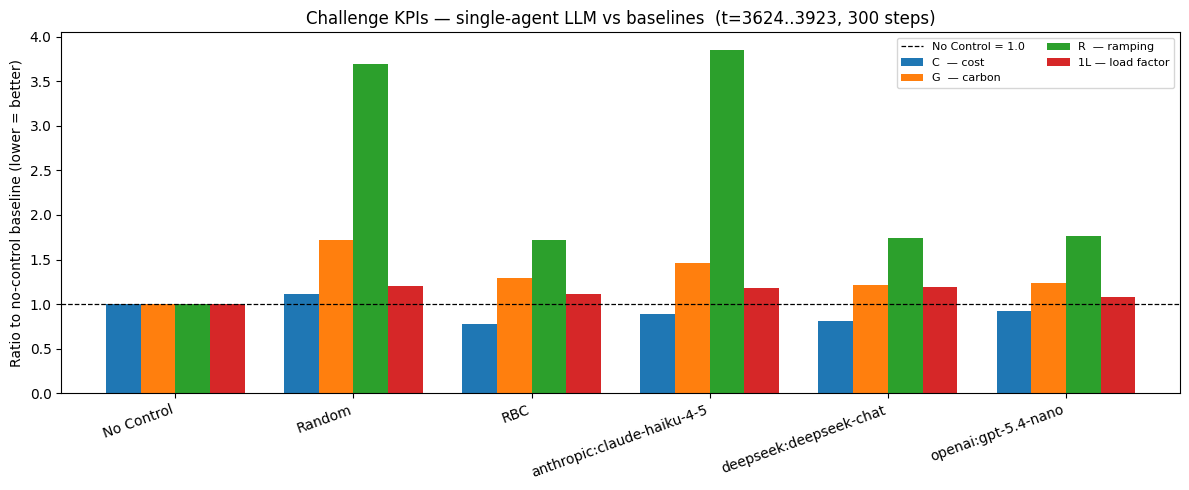

In [23]:
# Bar plot — Challenge KPIs (C, G, R, 1-L) per agent
kpi_cols = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor"]
ax = challenge_df[kpi_cols].plot(kind="bar", figsize=(12, 5), width=0.78)
ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
ax.set_ylabel("Ratio to no-control baseline (lower = better)")
ax.set_title(
    f"Challenge KPIs — single-agent LLM vs baselines  "
    f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## § 14 — Per-Building Breakdown


In [24]:
def per_building_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-building action/SoC/reward summary for a single-agent rollout."""
    rows = []
    for b in range(N_BLDGS):
        rows.append({
            "run":           label,
            "building":      f"B{b}",
            "total_reward":  float(df[f"r{b}"].sum()),
            "mean_soc_pct":  float(df[f"soc{b}"].mean() * 100),
            "peak_net_kW":   float(df[f"net{b}"].max()),
            "total_net_kWh": float(df[f"net{b}"].sum()),
            "mean_action":   float(df[f"a{b}"].mean()),
            "std_action":    float(df[f"a{b}"].std()),
        })
    return pd.DataFrame(rows)


if llm_runs:
    per_b = pd.concat([
        per_building_summary(run["df"], name)
        for name, run in llm_runs.items()
    ], ignore_index=True)
    print(f"Per-building breakdown (buildings {BUILDINGS}):")
    display(per_b.set_index(["run", "building"]).round(4))
else:
    print("No LLM runs in llm_runs yet — run provider cells above.")


Per-building breakdown (buildings [0, 1, 2]):


total_reward  mean_soc_pct  peak_net_kW  total_net_kWh  \
run       building                                                           
anthropic B0           -683.4705       70.2520       6.9116       289.4568   
          B1           -711.3505       70.3076       6.2061       351.9860   
          B2           -418.1200       73.1642       3.0760       121.0229   
deepseek  B0           -581.2730       73.8962       5.8797       273.6956   
          B1           -601.4480       72.7009       6.2061       337.1712   
          B2           -310.5170       74.1503       3.0760       107.8967   
openai    B0           -577.4169       84.6201       7.0537       271.6207   
          B1           -633.9658       79.5331       7.2061       337.9362   
          B2           -324.1614       61.3311       4.4719       111.5181   

                    mean_action  std_action  
run       building                           
anthropic B0             0.0334      0.2926  
          B1             0.0247      0.2738  
          B2             0.0254      0.2525  
deepseek  B0             0.0120      0.1914  
          B1             0.0120      0.1914  
          B2             0.0127      0.1824  
openai    B0             0.0120      0.1366  
          B1             0.0127      0.1646  
          B2             0.0134      0.1812

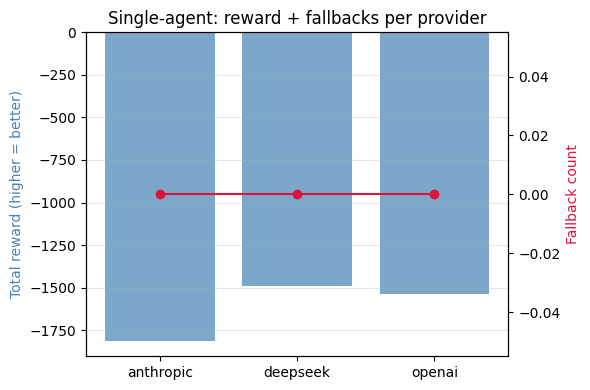

In [25]:
if llm_runs:
    fig, ax = plt.subplots(figsize=(6, 4))
    providers = list(llm_runs.keys())
    rewards   = [llm_runs[n]["df"]["reward_sum"].sum() for n in providers]
    fallbacks = [sum(1 for r in llm_runs[n]["raw_log"] if r["fallback"]) for n in providers]
    x = range(len(providers))
    ax2 = ax.twinx()
    ax.bar(x, rewards, alpha=0.7, color="steelblue", label="Total reward")
    ax2.plot(x, fallbacks, "o-", color="crimson", label="Fallbacks")
    ax.set_xticks(list(x)); ax.set_xticklabels(providers)
    ax.set_ylabel("Total reward (higher = better)", color="steelblue")
    ax2.set_ylabel("Fallback count", color="crimson")
    ax.set_title("Single-agent: reward + fallbacks per provider")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()


## § 15 — Diagnostics

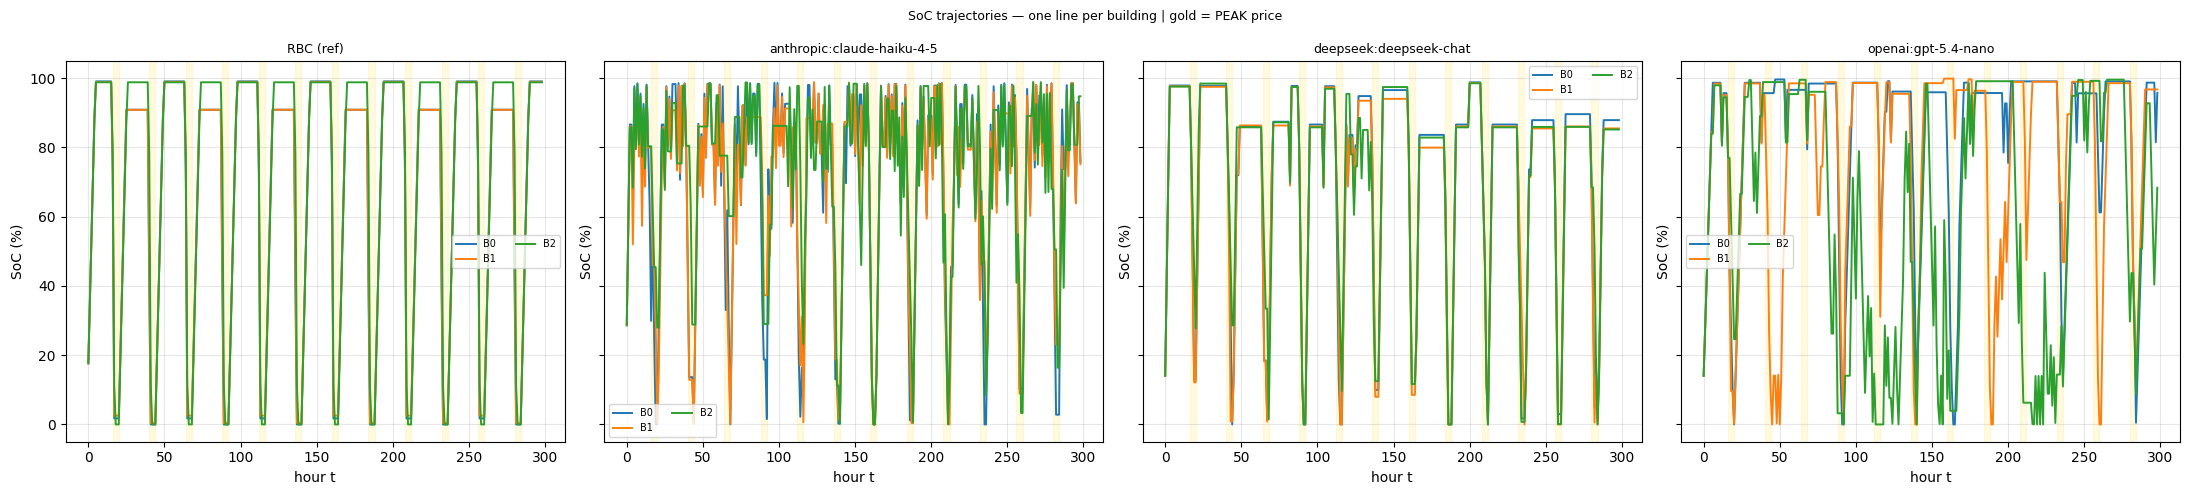

In [26]:
# 15.1  SoC trajectories — one line per building, PEAK price shaded
if not llm_runs:
    print("No LLM runs yet.")
else:
    panels = [(df_rbc, "RBC (ref)")] + [(run["df"], run["label"]) for run in llm_runs.values()]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 5), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    bldg_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for ax, (df_, label) in zip(axes, panels):
        for b in range(N_BLDGS):
            ax.plot(df_["t"], df_[f"soc{b}"] * 100,
                    label=f"B{b}", lw=1.4, color=bldg_colors[b % len(bldg_colors)])

        peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
        in_peak, span_s = False, 0
        for i_m, is_peak in enumerate(peak_mask):
            if is_peak and not in_peak:
                span_s = i_m; in_peak = True
            elif not is_peak and in_peak:
                ax.axvspan(span_s, i_m - 1, color="gold", alpha=0.12); in_peak = False
        if in_peak:
            ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

        ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
        ax.set_title(label, fontsize=9)
        ax.legend(ncol=2, fontsize=7); ax.grid(alpha=0.3)

    plt.suptitle("SoC trajectories — one line per building | gold = PEAK price", fontsize=9)
    plt.tight_layout()
    plt.show()


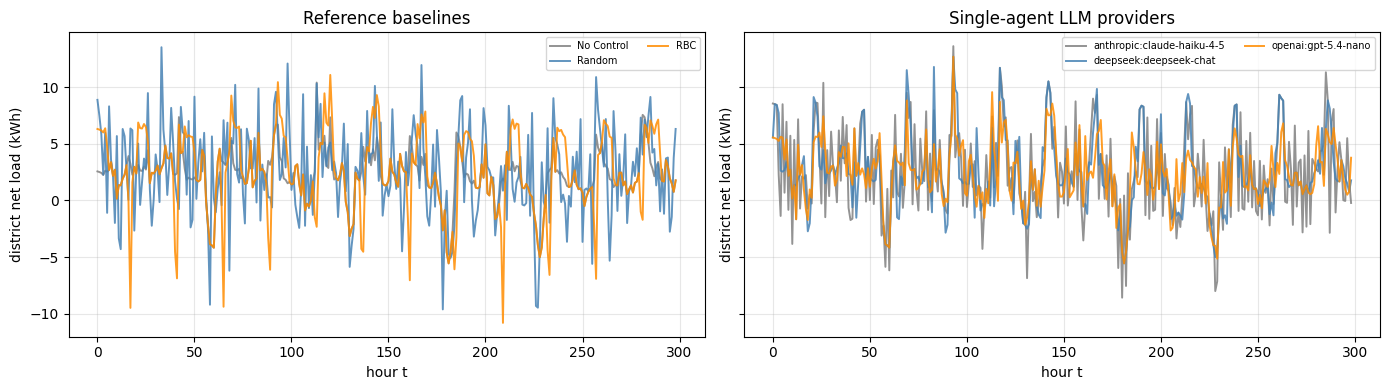

In [27]:
# 15.2  District net load comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

def _plot_net(ax, dfs_labels, title):
    colors = ["gray", "steelblue", "darkorange", "crimson", "forestgreen", "purple"]
    for (df_, lbl), color in zip(dfs_labels, colors):
        net = df_[[f"net{i}" for i in range(N_BLDGS)]].sum(axis=1)
        ax.plot(df_["t"], net, label=lbl, lw=1.4, color=color, alpha=0.85)
    ax.set_xlabel("hour t"); ax.set_ylabel("district net load (kWh)")
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ref_panels = [(df_noop, "No Control"), (df_random, "Random"), (df_rbc, "RBC")]
_plot_net(axes[0], ref_panels, "Reference baselines")

llm_panels = [(run["df"], run["label"]) for run in llm_runs.values()]
if llm_panels:
    _plot_net(axes[1], llm_panels, "Single-agent LLM providers")
else:
    axes[1].text(0.5, 0.5, "No LLM runs yet", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


In [28]:
# 15.3  Behavioural summary per provider (rule violations, action stats)
def analyze_run(run: dict) -> dict:
    df       = run["df"]
    raw_log  = run["raw_log"]
    a_cols   = [f"a{i}"   for i in range(N_BLDGS)]
    soc_cols = [f"soc{i}" for i in range(N_BLDGS)]
    A        = df[a_cols].values
    fb       = float(np.mean([r["fallback"] for r in raw_log])) if raw_log else 0.0
    SOC_post = df[soc_cols].values
    SOC_pre  = np.vstack([np.zeros(N_BLDGS), SOC_post[:-1]])
    return {
        "provider":           run["label"],
        "fallback_pct":       round(fb * 100, 1),
        "charge_at_full":     int(((A > 0) & (SOC_pre >= 0.9)).sum()),
        "discharge_at_empty": int(((A < 0) & (SOC_pre <= 0.1)).sum()),
        "mean_action":        round(float(A.mean()), 3),
        "std_action":         round(float(A.std()), 3),
    }


if llm_runs:
    beh_df = pd.DataFrame([analyze_run(run) for run in llm_runs.values()])
    print("Behavioural summary:")
    display(beh_df.set_index("provider").round(3))
    print(
        "\nfallback_pct = timeout + parse failures (target: 0).\n"
        "charge_at_full / discharge_at_empty = prompt-rule violations."
    )


Behavioural summary:


,fallback_pct,charge_at_full,discharge_at_empty,mean_action,std_action
provider,,,,,
anthropic:claude-haiku-4-5,0.0,0,1,0.028,0.273
deepseek:deepseek-chat,0.0,0,0,0.012,0.188
openai:gpt-5.4-nano,0.0,10,10,0.013,0.162



fallback_pct = timeout + parse failures (target: 0).
charge_at_full / discharge_at_empty = prompt-rule violations.


In [29]:
# 15.4  Sample raw responses — 1 timestep per provider
N_SHOW = 1

if not llm_runs:
    print("No LLM runs yet.")
else:
    rng_diag = np.random.default_rng(SEED)
    ref_log  = next(iter(llm_runs.values()))["raw_log"]
    picked   = sorted(rng_diag.choice(len(ref_log), size=min(N_SHOW, len(ref_log)), replace=False).tolist())

    for idx in picked:
        t_val = ref_log[idx]["t"]
        print("=" * 72)
        print(f"t={t_val}")
        for name, run in llm_runs.items():
            entry = run["raw_log"][idx]
            print(f"\n-- {run['label']} --")
            print(f"  State:\n{entry['state_text']}")
            print(f"  Response (fallback={entry['fallback']}):\n{entry['raw']}")
        print()


t=26

-- anthropic:claude-haiku-4-5 --
  State:
Month 12, Sat 01:00  |  price=0.210 (LOW)  |  carbon=0.186 (MID)
Buildings:
  B0: SoC= 69.4%  load=2.63 kWh  last_net=+0.55 kWh  solar=NONE
  B1: SoC= 68.7%  load=1.56 kWh  last_net=-0.04 kWh  solar=NONE
  B2: SoC= 67.7%  load=0.25 kWh  last_net=-0.78 kWh  solar=NONE
  Response (fallback=False):
<thought>
Low price, night (no solar), moderate loads. Charge to build reserves for peak hours ahead. All SoCs safe for charging.
</thought>

<action building=0>CHARGE_40</action>
<action building=1>CHARGE_40</action>
<action building=2>CHARGE_40</action>

-- deepseek:deepseek-chat --
  State:
Month 12, Sat 01:00  |  price=0.210 (LOW)  |  carbon=0.186 (MID)
Buildings:
  B0: SoC= 97.8%  load=2.63 kWh  last_net=+1.55 kWh  solar=NONE
  B1: SoC= 97.5%  load=1.56 kWh  last_net=+0.96 kWh  solar=NONE
  B2: SoC= 98.4%  load=0.25 kWh  last_net=+0.22 kWh  solar=NONE
  Response (fallback=False):
<thought>
All batteries near full, low load, low price. No sola

## § 16 — Save Artifacts

In [ ]:
stamp = time.strftime("%Y%m%d_%H%M%S")

# ── Rollout CSVs ──────────────────────────────────────────────────────────
all_dfs = [df_noop, df_random, df_rbc] + [run["df"] for run in llm_runs.values()]
df_all  = pd.concat(all_dfs, ignore_index=True)
csv_path = ARTIFACTS / f"02_rollouts_{stamp}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Rollout data    : {csv_path}")

# ── KPI tables (Challenge + ZNE via src.eval) ─────────────────────────────
kpi_path = ARTIFACTS / f"02_challenge_{stamp}.csv"
challenge_df.to_csv(kpi_path)
print(f"Challenge table : {kpi_path}")
zne_path = ARTIFACTS / f"02_zne_{stamp}.csv"
zne_df.to_csv(zne_path)
print(f"ZNE table       : {zne_path}")

# ── Per-building summary ──────────────────────────────────────────────────
if llm_runs:
    per_b_path = ARTIFACTS / f"02_per_building_{stamp}.csv"
    per_b.to_csv(per_b_path, index=False)
    print(f"Per-building    : {per_b_path}")

# ── Raw LLM logs (JSON) ───────────────────────────────────────────────────
for name, run in llm_runs.items():
    log_path = ARTIFACTS / f"02_raw_{name}_{stamp}.json"
    with open(log_path, "w") as f:
        json.dump(run["raw_log"], f, indent=2)
    print(f"Raw log {name:10s}: {log_path}")
